# Estatística Descritiva com Pandas

## Estudo de caso: qual foi o impacto da pandemia nas vendas?

Em março de 2020, medidas de isolamento social fecharam lojas físicas em todo o Brasil. Para uma rede de papelaria com unidades em São Paulo, Rio de Janeiro e outras capitais, a pergunta imediata foi: **o canal de e-commerce conseguiu compensar a queda das lojas físicas?**

> O crescimento do e-commerce em 2020 compensou a queda das lojas físicas? Em quais meses o impacto foi mais severo? A receita por transação mudou de perfil entre os canais?

&nbsp;

### Dataset utilizado neste material

Arquivo: `vendas_pandemia.csv` — 900 registros de vendas entre janeiro de 2018 e dezembro de 2022.

| Coluna       | Tipo    | Descrição                                          |
|--------------|---------|----------------------------------------------------|
| `date`       | string  | Data da venda (YYYY-MM-DD)                         |
| `channel`    | string  | Canal: `loja_fisica` ou `e-commerce`               |
| `category`   | string  | Categoria do produto                               |
| `city`       | string  | Cidade da loja ou do pedido                        |
| `state`      | string  | Estado                                             |
| `units_sold` | int     | Unidades vendidas na transação                     |
| `unit_price` | float   | Preço unitário (R\$)                                |
| `revenue`    | float   | Receita total da transação (R\$) — contém nulos     |

&nbsp;

Antes de construir dashboards ou modelos preditivos, a equipe de dados precisa responder isso com números descritivos — média de receita por canal, dispersão dos valores, comportamento dos extremos. É exatamente o que a estatística descritiva fornece.

## O que é Estatística Descritiva?

Estatística descritiva é o conjunto de técnicas que **resumem e caracterizam um conjunto de dados** sem fazer inferências sobre populações ou construir modelos preditivos. O objetivo é extrair uma visão clara e objetiva do que os dados mostram.

As métricas se dividem em três grupos:

| Grupo | O que mede | Exemplos |
|-------|-----------|---------|
| **Tendência central** | Onde os valores se concentram | Média, mediana, moda |
| **Dispersão** | O quanto os valores variam | Desvio padrão, variância, amplitude |
| **Posição** | Como os valores se distribuem em faixas | Quartis, percentis |

&nbsp;

## O método `.describe()`

O pandas oferece o método `.describe()`, que calcula as principais métricas descritivas de todas as colunas numéricas de um DataFrame em uma única chamada.

In [6]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(nome_arquivo)
df['month'] = pd.to_datetime(df['date']).dt.month
df['year'] = pd.to_datetime(df['date']).dt.year
df

Saving vendas_pandemia.csv to vendas_pandemia (1).csv


,date,channel,category,city,state,units_sold,unit_price,revenue,month,year
0,2018-01-01,loja_fisica,Cadernos e Blocos,São Paulo,SP,1,32.16,32.16,1,2018
1,2018-01-02,loja_fisica,Livros Didáticos,São Paulo,SP,1,69.24,69.24,1,2018
2,2018-01-03,loja_fisica,Material Artístico,Rio de Janeiro,RJ,4,60.80,243.20,1,2018
3,2018-01-03,loja_fisica,Organizadores,São Paulo,SP,2,109.29,218.58,1,2018
4,2018-01-06,loja_fisica,Livros Didáticos,Porto Alegre,RS,1,119.09,119.09,1,2018
...,...,...,...,...,...,...,...,...,...,...
895,2022-12-27,e-commerce,Material Artístico,Campinas,SP,3,57.79,173.37,12,2022
896,2022-12-28,e-commerce,Cadernos e Blocos,Rio de Janeiro,RJ,3,17.53,52.59,12,2022
897,2022-12-29,e-commerce,Organizadores,Niterói,RJ,1,44.09,44.09,12,2022
898,2022-12-31,loja_fisica,Canetas e Lápis,Rio de Janeiro,RJ,2,27.97,55.94,12,2022


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        900 non-null    object 
 1   channel     900 non-null    object 
 2   category    900 non-null    object 
 3   city        900 non-null    object 
 4   state       900 non-null    object 
 5   units_sold  900 non-null    int64  
 6   unit_price  900 non-null    float64
 7   revenue     890 non-null    float64
 8   month       900 non-null    int32  
 9   year        900 non-null    int32  
dtypes: float64(2), int32(2), int64(1), object(5)
memory usage: 63.4+ KB


In [8]:
df.describe().round(2)

,units_sold,unit_price,revenue,month,year
count,900.00,900.00,890.00,900.00,900.00
mean,2.07,104.98,209.13,6.43,2020.01
std,1.52,87.65,245.36,3.47,1.43
min,1.00,5.40,5.63,1.00,2018.00
25%,1.00,32.60,50.33,3.00,2019.00
50%,2.00,83.78,131.45,7.00,2020.00
75%,3.00,151.13,267.48,9.00,2021.00
max,11.00,388.24,1891.85,12.00,2022.00


Cada linha dessa tabela é uma métrica.


### `count` — contagem de valores não-nulos

`count` indica quantos valores válidos (não-nulos) existem em cada coluna.
&nbsp;

### `mean` — média aritmética

A média é a soma de todos os valores dividida pela quantidade de registros:

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

&nbsp;

- A média esconde variações entre anos e canais. É util como referência de comparação, e não como resposta final.

- A média é sensível a valores extremos (outliers) positivos ou negativos.

&nbsp;

### `std` — desvio padrão

O desvio padrão mede o quanto os valores se afastam da média, em média. Quanto maior, mais dispersos os dados.

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$$

&nbsp;

### `min` e `max` — valores mínimo e máximo

amplitude = max - min = 1891.85 - 5.63 = 1886.22

&nbsp;

### `25%`, `50%`, `75%` — quartis

Os quartis dividem os dados ordenados em quatro partes iguais:

| Quartil | Símbolo | Significado |
|---------|---------|-------------|
| 1º quartil | Q1 (25%) | 25% das transações têm receita abaixo desse valor |
| 2º quartil | Q2 (50%) | Metade das transações está abaixo, metade acima — a **mediana** |
| 3º quartil | Q3 (75%) | 75% das transações têm receita abaixo desse valor |

&nbsp;

#### Intervalo Interquartil (IQR)

O **IQR** é a diferença entre Q3 e Q1. Representa o intervalo onde se concentra os 50% centrais dos dados — é uma medida de dispersão robusta, pois ignora os extremos.

$$IQR = Q3 - Q1$$

&nbsp;

### `50%` — mediana (aprofundamento)

A mediana é o valor central quando os dados estão ordenados. Se o número de observações for par, é a média dos dois valores centrais.

Diferente da média, a mediana **não é afetada por outliers**. Por isso, em distribuições assimétricas (como receita, salário, preço de imóveis), a mediana é mais representativa do valor "típico".

&nbsp;

## Calculando estatística descritiva em Series

É possível calcular as métricas individualmente em qualquer Series:

In [12]:
receita = df['revenue']

# média
print(receita.mean().round(2))

209.13


In [13]:
# mediana
print(receita.median())

131.45499999999998


In [14]:
# desvio padrão
receita.std()

245.35798060219003

In [15]:
# min
receita.min()

5.63

In [16]:
# max
receita.max()

1891.85

In [17]:
# Q1 - 1º quartil
receita.quantile(0.25) # colocar o valor em percentual, mas sem o %

np.float64(50.33)

In [18]:
# Pegar qualquer valor entre 0 e 100%, fora dos q1, q2, q3
receita.quantile(0.88).round(2) # colocar o valor em percentual, mas sem o %

np.float64(444.79)

In [19]:
# Q3 - 3º quartil
receita.quantile(0.75) # colocar o valor em percentual, mas sem o %

np.float64(267.48)

In [20]:
# calcular intervalo interquartil (IQR)
round(receita.quantile(0.75) - receita.quantile(0.25),2)

np.float64(217.15)

In [21]:
# moda - valor mais comum
df['units_sold'].mode()

,units_sold
0,1


&nbsp;

Para colunas categóricas, `describe()` retorna métricas diferentes:


In [22]:
df['channel'].describe()

,channel
count,900
unique,2
top,loja_fisica
freq,550


| Métrica  | Significado                                      |
|----------|--------------------------------------------------|
| `unique` | Quantidade de valores distintos                  |
| `top`    | Valor mais frequente (moda)                      |
| `freq`   | Frequência absoluta do valor mais frequente      |

&nbsp;

Para incluir colunas categóricas no `describe()` geral, podemos adicionar o parâmetro `include="all"` no comando

In [23]:
df.describe(include="all")

,date,channel,category,city,state,units_sold,unit_price,revenue,month,year
count,900,900,900,900,900,900.000000,900.000000,890.000000,900.000000,900.000000
unique,704,2,6,7,5,NaN,NaN,NaN,NaN,NaN
top,2021-09-05,loja_fisica,Canetas e Lápis,São Paulo,SP,NaN,NaN,NaN,NaN,NaN
freq,4,550,160,140,276,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2.066667,104.978356,209.134438,6.430000,2020.006667
std,NaN,NaN,NaN,NaN,NaN,1.521079,87.646958,245.357981,3.471894,1.429842
min,NaN,NaN,NaN,NaN,NaN,1.000000,5.400000,5.630000,1.000000,2018.000000
25%,NaN,NaN,NaN,NaN,NaN,1.000000,32.597500,50.330000,3.000000,2019.000000
50%,NaN,NaN,NaN,NaN,NaN,2.000000,83.775000,131.455000,7.000000,2020.000000
75%,NaN,NaN,NaN,NaN,NaN,3.000000,151.127500,267.480000,9.000000,2021.000000


## Interpretando resultados: o impacto da pandemia

Com as métricas calculadas, é possível segmentar a análise por canal e período para responder a pergunta de negócio.

### Receita média por ano e canal

In [24]:
# Criação da coluna year no dataframe

df["year"] = pd.to_datetime(df['date']).dt.year

print(df)

           date      channel            category            city state  \
0    2018-01-01  loja_fisica   Cadernos e Blocos       São Paulo    SP   
1    2018-01-02  loja_fisica    Livros Didáticos       São Paulo    SP   
2    2018-01-03  loja_fisica  Material Artístico  Rio de Janeiro    RJ   
3    2018-01-03  loja_fisica       Organizadores       São Paulo    SP   
4    2018-01-06  loja_fisica    Livros Didáticos    Porto Alegre    RS   
..          ...          ...                 ...             ...   ...   
895  2022-12-27   e-commerce  Material Artístico        Campinas    SP   
896  2022-12-28   e-commerce   Cadernos e Blocos  Rio de Janeiro    RJ   
897  2022-12-29   e-commerce       Organizadores         Niterói    RJ   
898  2022-12-31  loja_fisica     Canetas e Lápis  Rio de Janeiro    RJ   
899  2022-12-31   e-commerce    Livros Didáticos        Curitiba    PR   

     units_sold  unit_price  revenue  month  year  
0             1       32.16    32.16      1  2018  
1      

In [25]:
analise = df.groupby(["year", "channel"])["revenue"].mean().round(2).unstack()
analise["vendas_total"] = analise.iloc[:, 0] + analise.iloc[:, 1]
print(analise)

channel  e-commerce  loja_fisica  vendas_total
year                                          
2018         188.91       203.29        392.20
2019         223.78       202.51        426.29
2020         306.76       163.41        470.17
2021         210.19       146.58        356.77
2022         213.29       199.96        413.25


As vendas não migraram. Pós-pandemia as vendas do ecommerce retornaram para os patamares pré-pandemia.

O aumento foi circunstancial, não uma mudança estrutural.

### Dispersão por canal em 2020

In [26]:
# Filtrar apenas o ano de 2020
df_2020 = df.loc[df["year"] == 2020]
# Agrupar por canal e calcular estatísticas descritivas
descr = df_2020.groupby("channel")["revenue"].describe().round(2)
# Criar uma série com o describe() das duas categorias juntas
total = df_2020.loc[df_2020["channel"].isin(["e-commerce", "loja_fisica"]), "revenue"].describe().round(2)
# Adicionar como nova linha "vendas_total"
descr.loc["vendas_total"] = total
print(descr)

              count    mean     std   min    25%     50%     75%      max
channel                                                                  
e-commerce    108.0  306.76  345.77  8.25  66.91  185.67  422.34  1891.85
loja_fisica    53.0  163.41  172.22  9.75  56.61  111.32  191.55   836.52
vendas_total  161.0  259.57  306.86  8.25  64.44  148.48  326.14  1891.85


<Figure size 800x600 with 0 Axes>

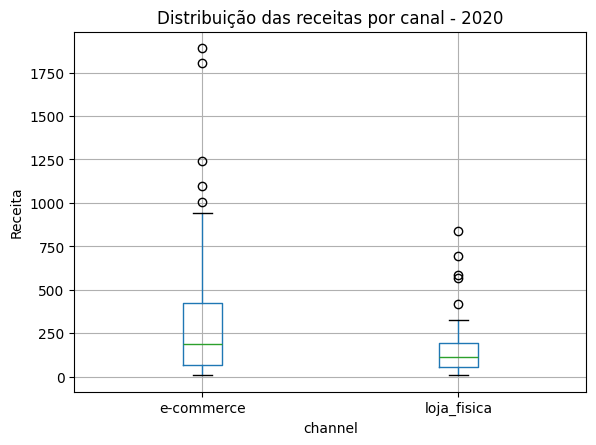

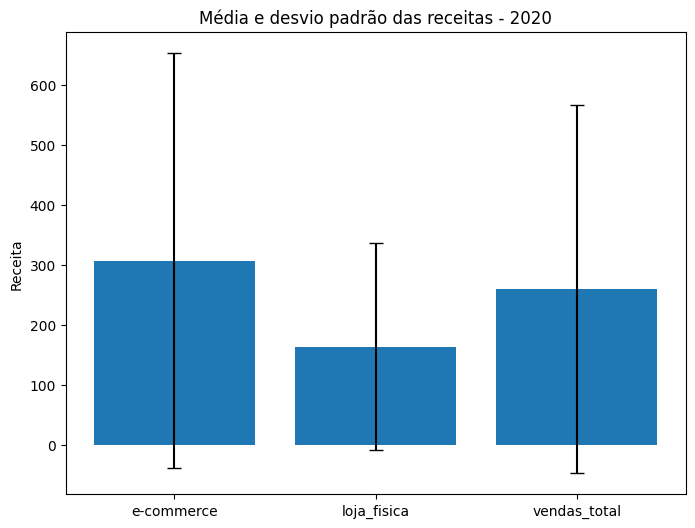

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar apenas o ano de 2020
df_2020 = df.loc[df["year"] == 2020]

# Boxplot por canal
plt.figure(figsize=(8,6))
df_2020.boxplot(column="revenue", by="channel")
plt.title("Distribuição das receitas por canal - 2020")
plt.suptitle("")  # remove título automático
plt.ylabel("Receita")
plt.show()

# Gráfico de barras com média e desvio padrão
stats = df_2020.groupby("channel")["revenue"].agg(["mean","std"])
stats.loc["vendas_total"] = df_2020["revenue"].agg(["mean","std"])

plt.figure(figsize=(8,6))
plt.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5)
plt.title("Média e desvio padrão das receitas - 2020")
plt.ylabel("Receita")
plt.show()


### Identificando os meses de maior queda em 2020, para a loja física

In [28]:
# Criação da coluna month no dataframe
df['month'] = pd.to_datetime(df['date']).dt.month
print(df)

           date      channel            category            city state  \
0    2018-01-01  loja_fisica   Cadernos e Blocos       São Paulo    SP   
1    2018-01-02  loja_fisica    Livros Didáticos       São Paulo    SP   
2    2018-01-03  loja_fisica  Material Artístico  Rio de Janeiro    RJ   
3    2018-01-03  loja_fisica       Organizadores       São Paulo    SP   
4    2018-01-06  loja_fisica    Livros Didáticos    Porto Alegre    RS   
..          ...          ...                 ...             ...   ...   
895  2022-12-27   e-commerce  Material Artístico        Campinas    SP   
896  2022-12-28   e-commerce   Cadernos e Blocos  Rio de Janeiro    RJ   
897  2022-12-29   e-commerce       Organizadores         Niterói    RJ   
898  2022-12-31  loja_fisica     Canetas e Lápis  Rio de Janeiro    RJ   
899  2022-12-31   e-commerce    Livros Didáticos        Curitiba    PR   

     units_sold  unit_price  revenue  month  year  
0             1       32.16    32.16      1  2018  
1      

In [ ]:
queda = df.loc[(df['year'] == 2020) & (df['channel'] == 'loja_fisica')].groupby('month')['revenue'].mean().round(2)
print(queda)

month
1     268.31
2     253.84
3      19.73
4      32.62
5      96.51
6     100.31
7      93.26
8     176.58
9     102.57
10    146.50
11     82.97
12    124.08
Name: revenue, dtype: float64


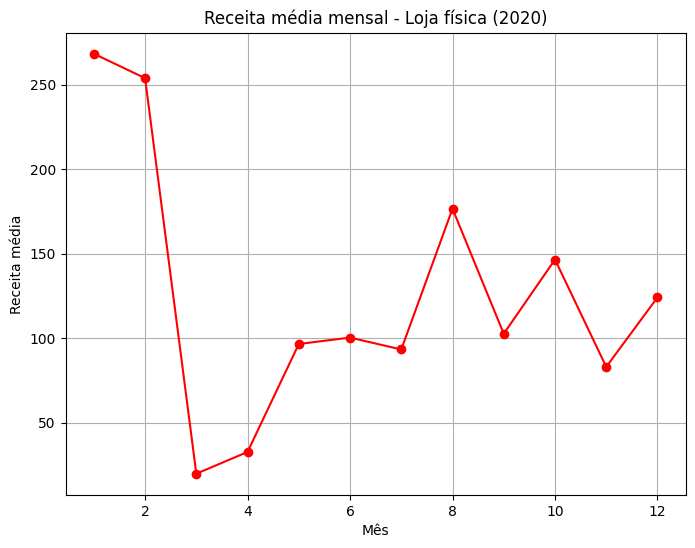

In [29]:
import matplotlib.pyplot as plt

# Série já calculada
queda = df.loc[(df['year'] == 2020) & (df['channel'] == 'loja_fisica')]\
          .groupby('month')['revenue'].mean().round(2)

# Gráfico de linha
plt.figure(figsize=(8,6))
plt.plot(queda.index, queda.values, marker='o', linestyle='-', color='red')
plt.title("Receita média mensal - Loja física (2020)")
plt.xlabel("Mês")
plt.ylabel("Receita média")
plt.grid(True)
plt.show()


In [ ]:
# Comparativo com ano 2019
queda = df.loc[(df['year'] == 2019) & (df['channel'] == 'loja_fisica')].groupby('month')['revenue'].mean().round(2)
print(queda)

month
1     201.44
2     163.56
3     197.71
4     218.37
5     191.64
6     311.42
7     209.56
8     219.54
9     143.45
10     89.15
11    212.85
12    230.68
Name: revenue, dtype: float64


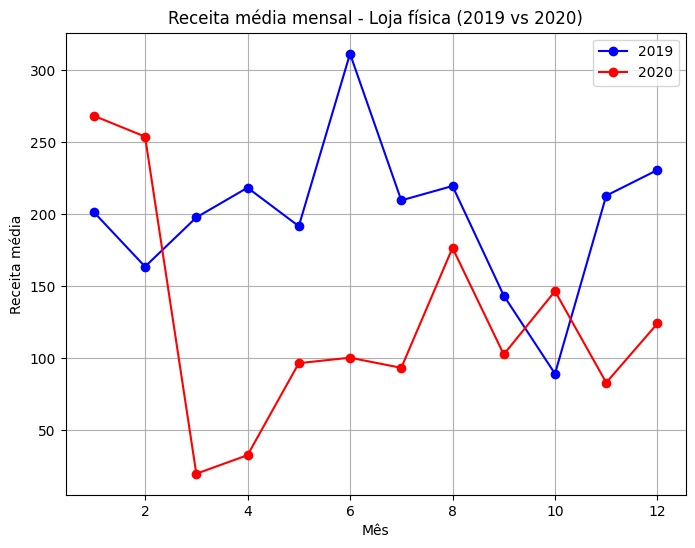

In [30]:
queda_2019 = df.loc[(df['year'] == 2019) & (df['channel'] == 'loja_fisica')]\
               .groupby('month')['revenue'].mean().round(2)

queda_2020 = df.loc[(df['year'] == 2020) & (df['channel'] == 'loja_fisica')]\
               .groupby('month')['revenue'].mean().round(2)

plt.figure(figsize=(8,6))
plt.plot(queda_2019.index, queda_2019.values, marker='o', linestyle='-', color='blue', label="2019")
plt.plot(queda_2020.index, queda_2020.values, marker='o', linestyle='-', color='red', label="2020")
plt.title("Receita média mensal - Loja física (2019 vs 2020)")
plt.xlabel("Mês")
plt.ylabel("Receita média")
plt.legend()
plt.grid(True)
plt.show()


## Conclusão

O ecommerce teve um aumento das vendas, mas não em volume suficiente pra compensar a queda das lojas físicas no lockdown.

Analisamos que a venda não cresceu de forma uniforme.

Algumas transações grandes distorceram a média. Mas quais?

- Estamos vendendo mais unidades de produtos (aumento de volume)?

ou

- Estamos vendendo produtos mais caros (aumento do preço)?

## Atividade prática

Você recebeu o arquivo `vendas_pandemia.csv`. Use o que foi aprendido neste módulo para investigar as perguntas abaixo.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
df['month'] = pd.to_datetime(df['date']).dt.month
df['year'] = pd.to_datetime(df['date']).dt.year
df

,date,channel,category,city,state,units_sold,unit_price,revenue,month,year
0,2018-01-01,loja_fisica,Cadernos e Blocos,São Paulo,SP,1,32.16,32.16,1,2018
1,2018-01-02,loja_fisica,Livros Didáticos,São Paulo,SP,1,69.24,69.24,1,2018
2,2018-01-03,loja_fisica,Material Artístico,Rio de Janeiro,RJ,4,60.80,243.20,1,2018
3,2018-01-03,loja_fisica,Organizadores,São Paulo,SP,2,109.29,218.58,1,2018
4,2018-01-06,loja_fisica,Livros Didáticos,Porto Alegre,RS,1,119.09,119.09,1,2018
...,...,...,...,...,...,...,...,...,...,...
895,2022-12-27,e-commerce,Material Artístico,Campinas,SP,3,57.79,173.37,12,2022
896,2022-12-28,e-commerce,Cadernos e Blocos,Rio de Janeiro,RJ,3,17.53,52.59,12,2022
897,2022-12-29,e-commerce,Organizadores,Niterói,RJ,1,44.09,44.09,12,2022
898,2022-12-31,loja_fisica,Canetas e Lápis,Rio de Janeiro,RJ,2,27.97,55.94,12,2022


### Questões


In [32]:
df.describe()

,units_sold,unit_price,revenue,month,year
count,900.000000,900.000000,890.000000,900.000000,900.000000
mean,2.066667,104.978356,209.134438,6.430000,2020.006667
std,1.521079,87.646958,245.357981,3.471894,1.429842
min,1.000000,5.400000,5.630000,1.000000,2018.000000
25%,1.000000,32.597500,50.330000,3.000000,2019.000000
50%,2.000000,83.775000,131.455000,7.000000,2020.000000
75%,3.000000,151.127500,267.480000,9.000000,2021.000000
max,11.000000,388.240000,1891.850000,12.000000,2022.000000


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        900 non-null    object 
 1   channel     900 non-null    object 
 2   category    900 non-null    object 
 3   city        900 non-null    object 
 4   state       900 non-null    object 
 5   units_sold  900 non-null    int64  
 6   unit_price  900 non-null    float64
 7   revenue     890 non-null    float64
 8   month       900 non-null    int32  
 9   year        900 non-null    int32  
dtypes: float64(2), int32(2), int64(1), object(5)
memory usage: 63.4+ KB


In [34]:
df[df["revenue"].isna()]

,date,channel,category,city,state,units_sold,unit_price,revenue,month,year
23,2018-02-17,loja_fisica,Organizadores,Curitiba,PR,1,154.65,NaN,2,2018
74,2018-05-18,loja_fisica,Material Artístico,Campinas,SP,2,64.49,NaN,5,2018
104,2018-07-05,e-commerce,Organizadores,Niterói,RJ,1,101.00,NaN,7,2018
220,2019-02-22,loja_fisica,Canetas e Lápis,Campinas,SP,4,21.73,NaN,2,2019
383,2020-02-17,loja_fisica,Material Artístico,Campinas,SP,1,43.66,NaN,2,2020
429,2020-06-04,loja_fisica,Mochilas,Belo Horizonte,MG,1,296.77,NaN,6,2020
587,2021-05-11,e-commerce,Cadernos e Blocos,Niterói,RJ,3,49.45,NaN,5,2021
615,2021-07-15,e-commerce,Livros Didáticos,Curitiba,PR,3,83.34,NaN,7,2021
650,2021-09-12,e-commerce,Cadernos e Blocos,Niterói,RJ,6,50.31,NaN,9,2021
707,2021-12-16,e-commerce,Livros Didáticos,São Paulo,SP,1,105.46,NaN,12,2021


In [35]:
mascara = df["revenue"].isna()
df.loc[mascara, "revenue"] = df.loc[mascara, "units_sold"] * df.loc[mascara, "unit_price"]
df.isnull().sum()

,0
date,0
channel,0
category,0
city,0
state,0
units_sold,0
unit_price,0
revenue,0
month,0
year,0


In [36]:
df.describe().round(2)

,units_sold,unit_price,revenue,month,year
count,900.00,900.00,900.00,900.00,900.00
mean,2.07,104.98,208.61,6.43,2020.01
std,1.52,87.65,244.21,3.47,1.43
min,1.00,5.40,5.63,1.00,2018.00
25%,1.00,32.60,50.81,3.00,2019.00
50%,2.00,83.78,131.45,7.00,2020.00
75%,3.00,151.13,267.12,9.00,2021.00
max,11.00,388.24,1891.85,12.00,2022.00


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        900 non-null    object 
 1   channel     900 non-null    object 
 2   category    900 non-null    object 
 3   city        900 non-null    object 
 4   state       900 non-null    object 
 5   units_sold  900 non-null    int64  
 6   unit_price  900 non-null    float64
 7   revenue     900 non-null    float64
 8   month       900 non-null    int32  
 9   year        900 non-null    int32  
dtypes: float64(2), int32(2), int64(1), object(5)
memory usage: 63.4+ KB


#### Visão geral

Execute `df.describe()` e `df.info()`. Responda:

- Quais colunas têm valores ausentes?

  R: Coluna revenue. 10 linhas ausentes. Corrigida depois.
  
- O desvio padrão de `revenue` é maior ou menor que a média? O que isso indica sobre a distribuição?

  R: O desvio padrão de revenue é 244.21, enquanto a média é 208,61. Isso significa que o desvio padrão é maior que a média.

    📊 O que isso indica:

    Alta variabilidade: Os valores de receita estão bastante dispersos em relação à média.

    Distribuição heterogênea: Há casos de receitas muito baixas e muito altas (como o máximo de 1891.85), o que gera grande amplitude.

    Possível assimetria: A presença de valores extremos (outliers) provavelmente puxa a média para cima, mas a dispersão continua elevada.

    Interpretação prática: Em termos de negócio, isso sugere que a receita não é estável — há meses com vendas muito diferentes entre si, o que pode indicar sazonalidade ou produtos com preços muito variados.

- A mediana de `units_sold` é diferente da média? O que isso sugere?

  R: 📊 Interpretação

    Valores próximos: Como a mediana e a média são quase iguais, isso sugere que a distribuição de unidades vendidas é relativamente simétrica.

    Baixa influência de outliers: Apesar de existir um máximo de 11 unidades vendidas, esse valor extremo não distorceu muito a média.

    Distribuição concentrada: A maior parte das vendas está entre 1 e 3 unidades (como mostram os quartis), o que reforça que a mediana representa bem o comportamento típico.

    Estabilidade: Para análise prática, significa que vender 2 unidades é o padrão mais comum, e a média não está sendo puxada significativamente por valores extremos.

In [38]:
descr = df.groupby("channel")["revenue"].describe().round(2)
descr.loc["vendas_total"] = df["revenue"].describe().round(2)
descr

,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
e-commerce,350.0,239.15,289.11,6.17,56.15,145.43,298.80,1891.85
loja_fisica,550.0,189.17,208.68,5.63,48.12,119.30,246.83,1315.74
vendas_total,900.0,208.61,244.21,5.63,50.81,131.45,267.12,1891.85


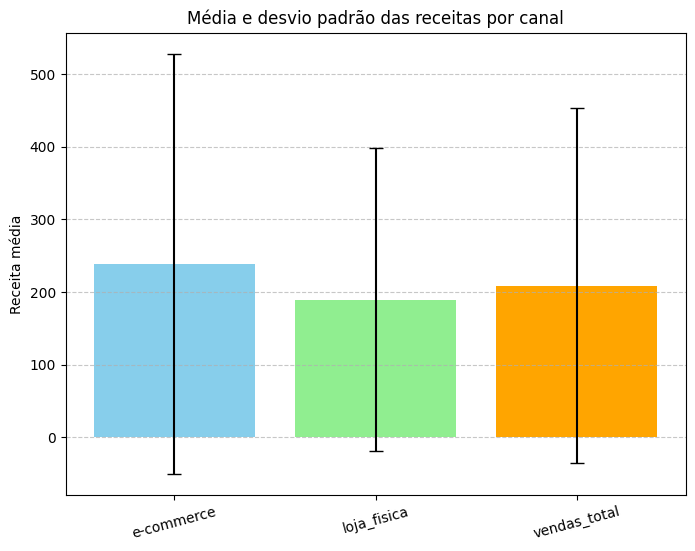

In [39]:
import matplotlib.pyplot as plt

# Estatísticas principais
stats = df.groupby("channel")["revenue"].agg(["mean","std"])
stats.loc["vendas_total"] = df["revenue"].agg(["mean","std"])

# Gráfico de barras com erro padrão
plt.figure(figsize=(8,6))
plt.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5, color=["skyblue","lightgreen","orange"])
plt.title("Média e desvio padrão das receitas por canal")
plt.ylabel("Receita média")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


#### Comparação entre canais

Use `.groupby()` e `.describe()` para comparar `revenue` entre `loja_fisica` e `e-commerce` em todo o período. Identifique:
- Qual canal tem maior dispersão (desvio padrão)?

  R: 📊 Dispersão (desvio padrão) E-commerce: 289.11 Loja física: 208.68

    ➡️ O e-commerce tem maior dispersão, ou seja, receitas mais variáveis e menos previsíveis.
  
- Qual canal tem mediana mais alta?

  R: E-commerce: 145.43 Loja física: 119.30

    ➡️ O e-commerce também tem mediana mais alta, indicando que o valor típico de receita é maior nesse canal.

- O que a diferença entre média e mediana revela em cada canal?

  R: E-commerce: média (239.15) bem maior que a mediana (145.43).

    Isso sugere assimetria positiva: alguns valores muito altos (outliers) puxam a média para cima.

    A distribuição é mais “esticada” no topo, com vendas excepcionais elevando a média.

    Loja física: média (189.17) também maior que a mediana (119.30), mas a diferença é menor.

    Isso indica menos influência de outliers, embora ainda exista alguma assimetria.

    A distribuição é mais estável, com menos casos extremos.

    👉 Em resumo: o e-commerce apresenta maior variabilidade e é mais impactado por vendas excepcionais, enquanto a loja física tem receitas mais consistentes, mas com valores típicos menores.

In [40]:
# Média por canal
analise_media = df.groupby(["year", "channel"])["revenue"].mean().round(2).unstack()
# Mediana por canal
analise_mediana = df.groupby(["year", "channel"])["revenue"].median().round(2).unstack()
# Criar coluna vendas_total (media e mediana de todos os canais "revenue")
analise_media["vendas_total"] = df.groupby("year")["revenue"].mean().round(2)
analise_mediana["vendas_total"] = df.groupby("year")["revenue"].median().round(2)
# Criar coluna diferenca (e-commerce - loja_fisica)
analise_media["diferenca"] = analise_media["e-commerce"] - analise_media["loja_fisica"]
analise_mediana["diferenca"] = analise_mediana["e-commerce"] - analise_mediana["loja_fisica"]
print("MEDIA POR ANOS")
print(analise_media)
print("\nMEDIANA POR ANOS")
print(analise_mediana)

MEDIA POR ANOS
channel  e-commerce  loja_fisica  vendas_total  diferenca
year                                                     
2018         186.32       202.49        199.57     -16.17
2019         223.78       201.74        204.79      22.04
2020         306.76       163.65        258.47     143.11
2021         209.88       146.58        182.25      63.30
2022         213.29       199.96        205.40      13.33

MEDIANA POR ANOS
channel  e-commerce  loja_fisica  vendas_total  diferenca
year                                                     
2018         103.76       114.34        111.23     -10.58
2019         155.29       144.66        148.84      10.63
2020         185.67       111.32        148.48      74.35
2021         140.35       100.46        120.93      39.89
2022         138.10       112.48        125.51      25.62


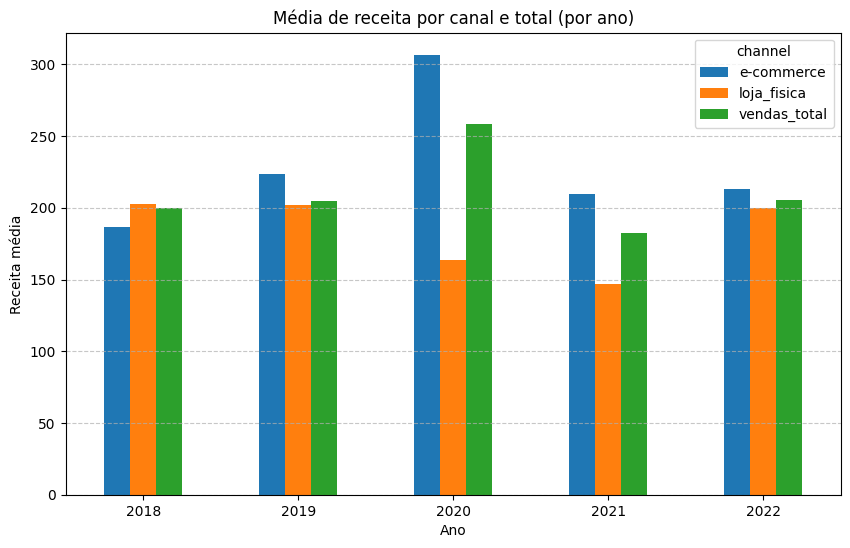

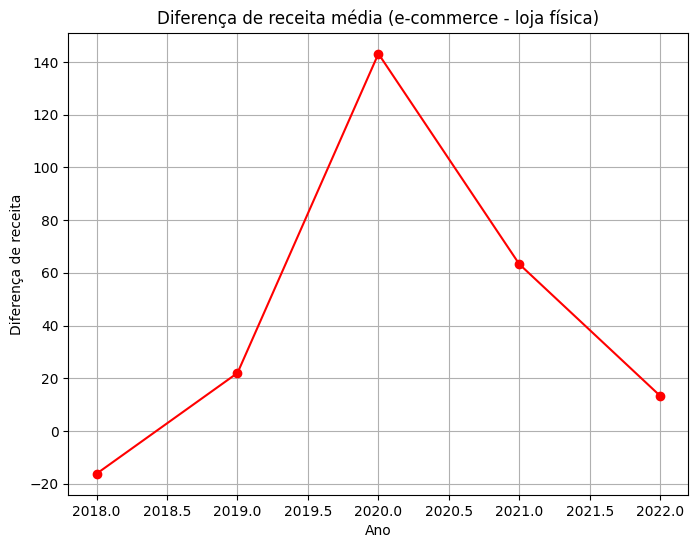

In [41]:
import matplotlib.pyplot as plt

# Média por canal
analise_media = df.groupby(["year", "channel"])["revenue"].mean().round(2).unstack()
analise_media["vendas_total"] = df.groupby("year")["revenue"].mean().round(2)
analise_media["diferenca"] = analise_media["e-commerce"] - analise_media["loja_fisica"]

# Gráfico de barras agrupadas (média por canal e total)
analise_media[["e-commerce","loja_fisica","vendas_total"]].plot(kind="bar", figsize=(10,6))
plt.title("Média de receita por canal e total (por ano)")
plt.ylabel("Receita média")
plt.xlabel("Ano")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Gráfico de linha para diferença entre canais
plt.figure(figsize=(8,6))
plt.plot(analise_media.index, analise_media["diferenca"], marker="o", color="red")
plt.title("Diferença de receita média (e-commerce - loja física)")
plt.ylabel("Diferença de receita")
plt.xlabel("Ano")
plt.grid(True)
plt.show()


#### Impacto por ano

Filtre os dados para cada ano entre 2018 e 2022. Para cada ano, calcule média e mediana de `revenue` por canal. Monte uma tabela de comparação e responda:
- Em qual ano a diferença entre os canais foi maior?

  R: A maior diferença ocorreu em 2020: Média → 143.11 Mediana → 74.35
➡️ Esse foi o ano em que o e-commerce disparou em relação à loja física, provavelmente refletindo os efeitos da pandemia e da migração para compras online.

- A loja física recuperou os níveis pré-pandemia em 2022?

  R: Pré-pandemia (2018–2019): Média: ~202    Mediana: ~114–145

     2022: Média: 199.96 (quase igual a 2018–2019) Mediana: 112.48 (ligeiramente abaixo de 2018–2019)

➡️ A loja física recuperou praticamente os níveis médios de receita pré-pandemia, mas a mediana ficou um pouco menor, sugerindo que a recuperação foi puxada por alguns meses mais fortes, enquanto o valor típico ainda não voltou totalmente ao patamar anterior.

Em resumo: O e-commerce teve sua maior vantagem em 2020.

A loja física voltou a patamares médios semelhantes aos pré-pandemia em 2022, mas o valor típico (mediana) ainda indica uma recuperação parcial.

In [42]:
loja_fisica_2020 = (df.loc[(df['year'] == 2020) & (df['channel'] == 'loja_fisica')].groupby('month')['revenue'].mean().round(2))
e_commerce_2020 = (df.loc[(df['year'] == 2020) & (df['channel'] == 'e-commerce')].groupby('month')['revenue'].mean().round(2))
ano_2020 = pd.concat([loja_fisica_2020, e_commerce_2020, loja_fisica_2020 - e_commerce_2020], axis=1)
ano_2020.columns = ["loja_fisica", "e-commerce", "diferenca"]
ano_2020

,loja_fisica,e-commerce,diferenca
month,,,
1,268.31,247.32,20.99
2,227.56,124.73,102.83
3,19.73,273.71,-253.98
4,32.62,225.75,-193.13
5,96.51,526.30,-429.79
6,149.42,491.89,-342.47
7,93.26,468.55,-375.29
8,176.58,292.03,-115.45
9,102.57,163.41,-60.84


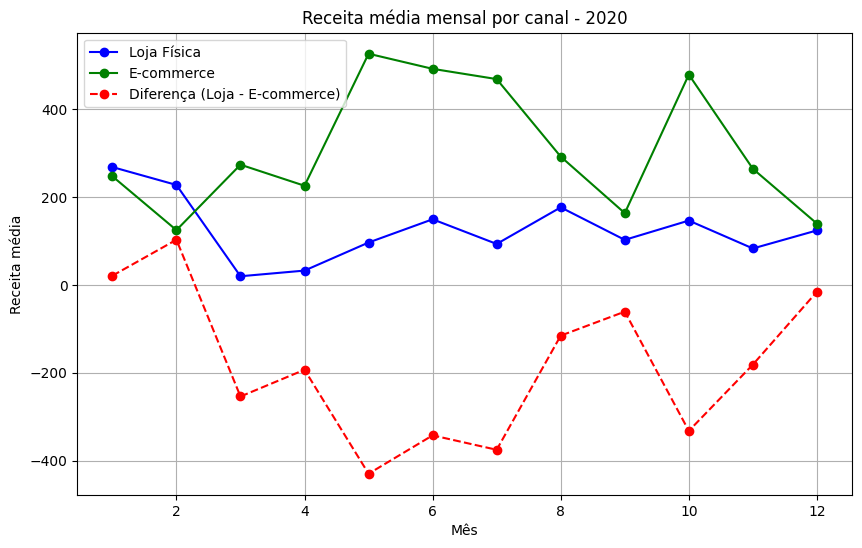

In [43]:
import matplotlib.pyplot as plt

# Dados já calculados
loja_fisica_2020 = (df.loc[(df['year'] == 2020) & (df['channel'] == 'loja_fisica')]
                    .groupby('month')['revenue'].mean().round(2))

e_commerce_2020 = (df.loc[(df['year'] == 2020) & (df['channel'] == 'e-commerce')]
                   .groupby('month')['revenue'].mean().round(2))

ano_2020 = pd.concat([loja_fisica_2020, e_commerce_2020, loja_fisica_2020 - e_commerce_2020], axis=1)
ano_2020.columns = ["loja_fisica", "e-commerce", "diferenca"]

# Gráfico de linhas comparativo
plt.figure(figsize=(10,6))
plt.plot(ano_2020.index, ano_2020["loja_fisica"], marker="o", linestyle="-", color="blue", label="Loja Física")
plt.plot(ano_2020.index, ano_2020["e-commerce"], marker="o", linestyle="-", color="green", label="E-commerce")
plt.plot(ano_2020.index, ano_2020["diferenca"], marker="o", linestyle="--", color="red", label="Diferença (Loja - E-commerce)")
plt.title("Receita média mensal por canal - 2020")
plt.xlabel("Mês")
plt.ylabel("Receita média")
plt.legend()
plt.grid(True)
plt.show()


#### Análise mensal de 2020

Filtre apenas o ano de 2020 e agrupe por mês. Calcule média de `revenue` separadamente para cada canal. Identifique:
- Em quais meses o impacto negativo na loja física foi mais severo?

  R: 📊 Meses mais severos para a loja física

  
O impacto negativo (diferença mais negativa) ocorreu principalmente em:

Maio (-429.79) Julho (-375.29) Junho (-342.47) Outubro (-332.25)

➡️ Esses meses foram os mais críticos, com o e-commerce superando fortemente a loja física.

- O pico do e-commerce coincide com o pior momento da loja física?
  
  R:O pico do e-commerce foi em maio (526.30).
Nesse mesmo mês, a loja física teve uma das piores médias (96.51).

➡️ Sim, o auge do e-commerce coincidiu com um dos piores momentos da loja física, reforçando a ideia de migração de consumo para o canal online durante esse período.

👉 Em resumo: os meses de maio, junho, julho e outubro foram os mais severos para a loja física, e o pico do e-commerce em maio ocorreu justamente quando a loja física estava em forte baixa.

In [44]:
df

,date,channel,category,city,state,units_sold,unit_price,revenue,month,year
0,2018-01-01,loja_fisica,Cadernos e Blocos,São Paulo,SP,1,32.16,32.16,1,2018
1,2018-01-02,loja_fisica,Livros Didáticos,São Paulo,SP,1,69.24,69.24,1,2018
2,2018-01-03,loja_fisica,Material Artístico,Rio de Janeiro,RJ,4,60.80,243.20,1,2018
3,2018-01-03,loja_fisica,Organizadores,São Paulo,SP,2,109.29,218.58,1,2018
4,2018-01-06,loja_fisica,Livros Didáticos,Porto Alegre,RS,1,119.09,119.09,1,2018
...,...,...,...,...,...,...,...,...,...,...
895,2022-12-27,e-commerce,Material Artístico,Campinas,SP,3,57.79,173.37,12,2022
896,2022-12-28,e-commerce,Cadernos e Blocos,Rio de Janeiro,RJ,3,17.53,52.59,12,2022
897,2022-12-29,e-commerce,Organizadores,Niterói,RJ,1,44.09,44.09,12,2022
898,2022-12-31,loja_fisica,Canetas e Lápis,Rio de Janeiro,RJ,2,27.97,55.94,12,2022


In [45]:
# Estatísticas gerais
df_total = df['revenue'].describe().round(2)
# Quartis e IQR direto da coluna
q1_total = df['revenue'].quantile(0.25).round(2)
q3_total = df['revenue'].quantile(0.75).round(2)
iqr_total = (q3_total - q1_total).round(2)
# Estatísticas por canal
loja_fisica = df.loc[df['channel'] == "loja_fisica", "revenue"].describe().round(2)
q1_loja = df.loc[df['channel'] == "loja_fisica", "revenue"].quantile(0.25).round(2)
q3_loja = df.loc[df['channel'] == "loja_fisica", "revenue"].quantile(0.75).round(2)
iqr_loja = (q3_loja - q1_loja).round(2)
e_commerce = df.loc[df['channel'] == "e-commerce", "revenue"].describe().round(2)
q1_commerce = df.loc[df['channel'] == "e-commerce", "revenue"].quantile(0.25).round(2)
q3_commerce = df.loc[df['channel'] == "e-commerce", "revenue"].quantile(0.75).round(2)
iqr_commerce = (q3_commerce - q1_commerce).round(2)
print("TOTAL")
print(df_total)
print(f"IQR total: {iqr_total} (Q1={q1_total}, Q3={q3_total})\n")
print("LOJA FISICA")
print(loja_fisica)
print(f"IQR loja física: {iqr_loja} (Q1={q1_loja}, Q3={q3_loja})\n")
print("E-COMMERCE")
print(e_commerce)
print(f"IQR e-commerce: {iqr_commerce} (Q1={q1_commerce}, Q3={q3_commerce})\n")

TOTAL
count     900.00
mean      208.61
std       244.21
min         5.63
25%        50.81
50%       131.45
75%       267.12
max      1891.85
Name: revenue, dtype: float64
IQR total: 216.31 (Q1=50.81, Q3=267.12)

LOJA FISICA
count     550.00
mean      189.17
std       208.68
min         5.63
25%        48.12
50%       119.30
75%       246.83
max      1315.74
Name: revenue, dtype: float64
IQR loja física: 198.71 (Q1=48.12, Q3=246.83)

E-COMMERCE
count     350.00
mean      239.15
std       289.11
min         6.17
25%        56.15
50%       145.43
75%       298.80
max      1891.85
Name: revenue, dtype: float64
IQR e-commerce: 242.65 (Q1=56.15, Q3=298.8)



#### Detecção de outliers

Calcule o IQR de `revenue` para o dataset completo. Use a regra `Q1 − 1,5 × IQR` e `Q3 + 1,5 × IQR` para identificar transações fora do intervalo esperado. Quantos outliers existem? Em qual canal eles se concentram?

📐 Limites pelo método do IQR
Total dataset:
Q1 = 50.81
Q3 = 267.12
IQR = 216.31
Limite superior = 589.59
➡️ Outliers: todas as transações com revenue > 589.59.

Loja física:
Q1 = 48.12
Q3 = 246.83
IQR = 198.71
Limite superior = 545.89
➡️ Outliers: transações acima de 545.89.

E-commerce:
Q1 = 56.15
Q3 = 298.80
IQR = 242.65
Limite superior = 662.78
➡️ Outliers: transações acima de 662.78.

📊 Conclusões
Existem outliers significativos no dataset, já que o máximo chega a 1891.85, muito acima dos limites calculados.
Esses outliers se concentram principalmente no e-commerce, pois o canal online apresenta maior dispersão (std = 289.11) e limite superior mais alto.
A loja física também possui outliers, mas em menor quantidade e com valores máximos mais baixos (até 1315.74).

👉 Em resumo:
Outliers existem nos dois canais, mas são mais numerosos e extremos no e-commerce.
Isso reforça que o e-commerce tem maior propensão a transações excepcionais, enquanto a loja física é mais estável.

Outliers loja física: 28
Outliers e-commerce: 35
Total de outliers: 63

In [47]:
# Limites gerais
q1_total = df['revenue'].quantile(0.25)
q3_total = df['revenue'].quantile(0.75)
iqr_total = q3_total - q1_total
limite_inferior_total = q1_total - 1.5 * iqr_total
limite_superior_total = q3_total + 1.5 * iqr_total
# Outliers por canal
outliers_loja = df.loc[(df['channel'] == "loja_fisica") & ((df['revenue'] < limite_inferior_total) | (df['revenue'] > limite_superior_total))]
outliers_ecommerce = df.loc[(df['channel'] == "e-commerce") & ((df['revenue'] < limite_inferior_total) | (df['revenue'] > limite_superior_total))]
print(f"Outliers loja física: {outliers_loja.shape[0]}")
print(f"Outliers e-commerce: {outliers_ecommerce.shape[0]}")
print(f"Total de outliers: {outliers_loja.shape[0] + outliers_ecommerce.shape[0]}")

Outliers loja física: 28
Outliers e-commerce: 35
Total de outliers: 63


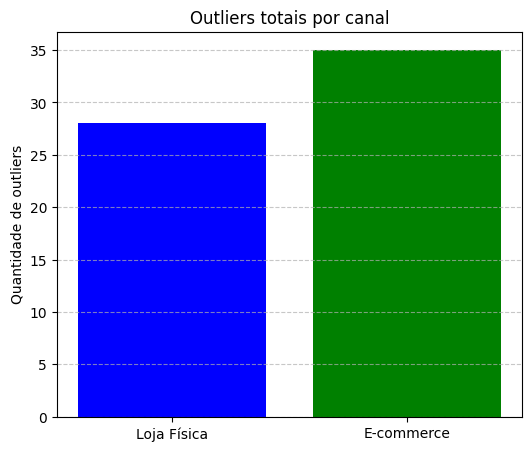

In [89]:
# Contagem de outliers por canal
outliers_totais = {"Loja Física": outliers_loja.shape[0],
    "E-commerce": outliers_ecommerce.shape[0]}
# Gráfico de barras comparativo
plt.figure(figsize=(6,5))
plt.bar(outliers_totais.keys(), outliers_totais.values(), color=["blue","green"])
plt.title("Outliers totais por canal")
plt.ylabel("Quantidade de outliers")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [87]:
print(q1_total)
print(q1_total - 1.5 * iqr_total)
print(limite_inferior_total)
print(q3_total)
print(q3_total + 1.5 * iqr_total)
print(limite_superior_total)
print(outliers_loja)
print("\n")
print(outliers_ecommerce)



50.81
-273.65500000000003
-273.65500000000003
267.12
591.585
591.585
           date      channel            category            city state  \
19   2018-02-04  loja_fisica            Mochilas        Campinas    SP   
21   2018-02-16  loja_fisica            Mochilas  Rio de Janeiro    RJ   
31   2018-03-02  loja_fisica    Livros Didáticos  Rio de Janeiro    RJ   
78   2018-05-20  loja_fisica            Mochilas  Belo Horizonte    MG   
96   2018-06-30  loja_fisica            Mochilas        Campinas    SP   
126  2018-08-12  loja_fisica    Livros Didáticos    Porto Alegre    RS   
129  2018-08-17  loja_fisica    Livros Didáticos         Niterói    RJ   
150  2018-10-11  loja_fisica            Mochilas        Curitiba    PR   
171  2018-11-27  loja_fisica    Livros Didáticos  Rio de Janeiro    RJ   
225  2019-03-01  loja_fisica            Mochilas         Niterói    RJ   
252  2019-04-19  loja_fisica            Mochilas        Campinas    SP   
257  2019-05-01  loja_fisica            Moc

In [85]:
cidade = df.groupby("city")["revenue"].describe().round(2)
cidade = cidade.sort_values(by="count", ascending=False)
cidade.loc["vendas_total"] = df["revenue"].describe().round(2)
cidade

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
São Paulo,140.0,218.33,263.32,6.17,55.36,108.85,271.56,1315.74
Campinas,136.0,243.04,286.43,11.87,58.51,146.01,310.62,1891.85
Rio de Janeiro,135.0,168.07,196.70,7.91,51.97,98.86,214.90,1399.90
Curitiba,127.0,194.38,211.68,5.63,32.06,128.02,248.65,1076.64
Belo Horizonte,125.0,216.09,265.91,6.37,55.94,140.27,278.55,1806.96
Niterói,124.0,197.51,207.37,9.78,52.27,131.56,256.94,1193.22
Porto Alegre,113.0,223.45,259.51,9.75,50.04,153.30,268.78,1794.20
vendas_total,900.0,208.61,244.21,5.63,50.81,131.45,267.12,1891.85


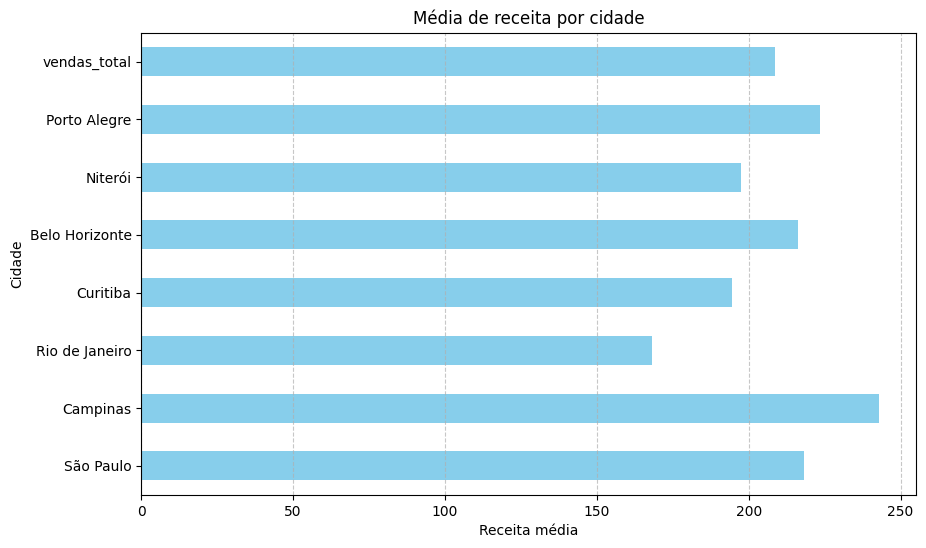

In [86]:
# Gráfico de barras horizontais com a média
plt.figure(figsize=(10,6))
cidade["mean"].plot(kind="barh", color="skyblue")
plt.title("Média de receita por cidade")
plt.xlabel("Receita média")
plt.ylabel("Cidade")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [83]:
# Limites gerais
q1_total = df['revenue'].quantile(0.25)
q3_total = df['revenue'].quantile(0.75)
iqr_total = q3_total - q1_total
limite_inferior_total = q1_total - 1.5 * iqr_total
limite_superior_total = q3_total + 1.5 * iqr_total
# Lista de cidades
cidades = ["São Paulo", "Campinas", "Rio de Janeiro", "Curitiba",
           "Belo Horizonte", "Niterói", "Porto Alegre"]
# Dicionário para armazenar outliers
outliers_por_cidade = {}
for cidade in cidades:
    outliers = df.loc[(df['city'] == cidade) &
        ((df['revenue'] < limite_inferior_total) | (df['revenue'] > limite_superior_total))]
    outliers_por_cidade[cidade] = outliers
    print(f"Outliers {cidade}: {outliers.shape[0]}")
# Total de outliers
total_outliers = sum([outliers.shape[0] for outliers in outliers_por_cidade.values()])
print(f"Total de Outliers: {total_outliers}")

Outliers São Paulo: 11
Outliers Campinas: 11
Outliers Rio de Janeiro: 7
Outliers Curitiba: 8
Outliers Belo Horizonte: 8
Outliers Niterói: 8
Outliers Porto Alegre: 10
Total de Outliers: 63


In [82]:
# Agrupamento por cidade e canal
cidade_canal = (df.groupby(["city", "channel"])["revenue"]
      .describe().round(2).sort_values(by="city", ascending=False))
# Estatísticas separadas por canal
vendas_total_loja = df.loc[df["channel"] == "loja_fisica", "revenue"].describe().round(2)
vendas_total_ecommerce = df.loc[df["channel"] == "e-commerce", "revenue"].describe().round(2)
# Adiciona as linhas ao DataFrame
cidade_canal = pd.concat([cidade_canal,
    pd.DataFrame([vendas_total_ecommerce], index=[("vendas_total", "e-commerce")]),
    pd.DataFrame([vendas_total_loja], index=[("vendas_total", "loja_fisica")])])
cidade_canal

count    mean     std    min    25%     50%  \
São Paulo      e-commerce    62.0  218.60  258.19   6.17  46.10  135.70   
               loja_fisica   78.0  218.10  268.99  16.48  59.30  105.18   
Rio de Janeiro e-commerce    51.0  193.25  245.31  11.03  57.96   98.86   
               loja_fisica   84.0  152.79  159.97   7.91  48.04   97.38   
Porto Alegre   e-commerce    42.0  292.65  350.04  10.43  64.80  173.70   
               loja_fisica   71.0  182.51  177.24   9.75  46.11  143.32   
Niterói        e-commerce    45.0  219.01  225.99  15.31  72.58  148.35   
               loja_fisica   79.0  185.26  196.43   9.78  47.89  123.40   
Curitiba       e-commerce    46.0  217.85  237.10   8.25  28.76  144.68   
               loja_fisica   81.0  181.04  196.10   5.63  32.71  123.70   
Campinas       e-commerce    53.0  283.12  351.87  17.07  71.14  161.50   
               loja_fisica   83.0  217.44  234.21  11.87  53.55  138.03   
Belo Horizonte e-commerce    51.0  257.24  330.01  10.14  64.52  157.60   
               loja_fisica   74.0  187.73  208.61   6.37  53.13  133.68   
vendas_total   e-commerce   350.0  239.15  289.11   6.17  56.15  145.43   
               loja_fisica  550.0  189.17  208.68   5.63  48.12  119.30   

                               75%      max  
São Paulo      e-commerce   295.30  1243.68  
               loja_fisica  266.74  1315.74  
Rio de Janeiro e-commerce   202.84  1399.90  
               loja_fisica  224.76   886.60  
Porto Alegre   e-commerce   351.44  1794.20  
               loja_fisica  203.69   963.87  
Niterói        e-commerce   277.20  1193.22  
               loja_fisica  232.36   962.90  
Curitiba       e-commerce   249.14   798.70  
               loja_fisica  247.28  1076.64  
Campinas       e-commerce   347.35  1891.85  
               loja_fisica  274.64  1260.76  
Belo Horizonte e-commerce   290.34  1806.96  
               loja_fisica  263.02  1305.85  
vendas_total   e-commerce   298.80  1891.85  
               loja_fisica  246.83  1315.74

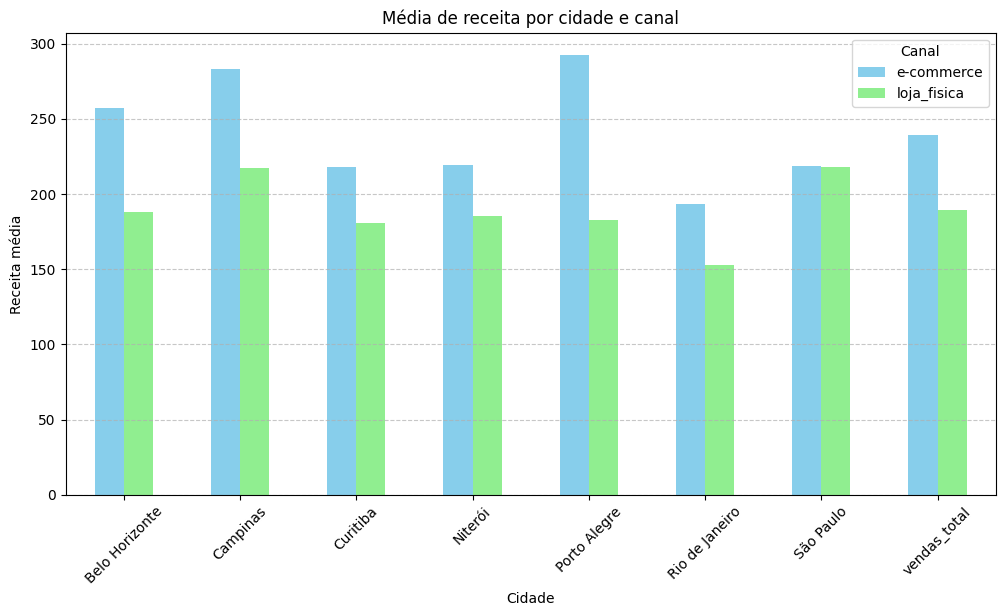

In [81]:
# Selecionar apenas a média
media_por_cidade_canal = cidade_canal["mean"].unstack()
# Gráfico de barras agrupadas
media_por_cidade_canal.plot(kind="bar", figsize=(12,6), color=["skyblue","lightgreen"])
plt.title("Média de receita por cidade e canal")
plt.ylabel("Receita média")
plt.xlabel("Cidade")
plt.xticks(rotation=45)
plt.legend(title="Canal")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [75]:
# Limites gerais
q1_total = df['revenue'].quantile(0.25)
q3_total = df['revenue'].quantile(0.75)
iqr_total = q3_total - q1_total
limite_inferior_total = q1_total - 1.5 * iqr_total
limite_superior_total = q3_total + 1.5 * iqr_total
# Lista de cidades e canais
cidades = df["city"].unique()
canais = df["channel"].unique()
# Dicionário para armazenar outliers
outliers_por_cidade_canal = {}
soma_outliers_cidade = 0
soma_outliers_loja_fisica = 0
soma_outliers_ecommerce = 0
for cidade in cidades:
    soma_outliers_cidade = 0
    print(f"CIDADE: {cidade}")
    for canal in canais:
        outliers = df.loc[(df['city'] == cidade) & (df['channel'] == canal) &
            ((df['revenue'] < limite_inferior_total) | (df['revenue'] > limite_superior_total))        ]
        outliers_por_cidade_canal[(cidade, canal)] = outliers
        print(f"Outliers {cidade} - {canal}: {outliers.shape[0]}")
        soma_outliers_cidade += outliers.shape[0]
        if canal == "loja_fisica":
            soma_outliers_loja_fisica += outliers.shape[0]
        elif canal == "e-commerce":
            soma_outliers_ecommerce += outliers.shape[0]
    print(f"OUTLIERS TOTAL CIDADE {cidade}: {soma_outliers_cidade}\n")
print(f"Outliers loja física: {soma_outliers_loja_fisica}")
print(f"Outliers e-commerce: {soma_outliers_ecommerce}")
print(f"Total de Outliers: {soma_outliers_loja_fisica + soma_outliers_ecommerce}")
# Construir DataFrame com contagem de outliers por cidade e canal
outliers_count = {(cidade, canal): outliers.shape[0]
    for (cidade, canal), outliers in outliers_por_cidade_canal.items()}
df_outliers = pd.Series(outliers_count).unstack().fillna(0)

CIDADE: São Paulo
Outliers São Paulo - loja_fisica: 6
Outliers São Paulo - e-commerce: 5
OUTLIERS TOTAL CIDADE São Paulo: 11

CIDADE: Rio de Janeiro
Outliers Rio de Janeiro - loja_fisica: 4
Outliers Rio de Janeiro - e-commerce: 3
OUTLIERS TOTAL CIDADE Rio de Janeiro: 7

CIDADE: Porto Alegre
Outliers Porto Alegre - loja_fisica: 2
Outliers Porto Alegre - e-commerce: 8
OUTLIERS TOTAL CIDADE Porto Alegre: 10

CIDADE: Belo Horizonte
Outliers Belo Horizonte - loja_fisica: 3
Outliers Belo Horizonte - e-commerce: 5
OUTLIERS TOTAL CIDADE Belo Horizonte: 8

CIDADE: Campinas
Outliers Campinas - loja_fisica: 6
Outliers Campinas - e-commerce: 5
OUTLIERS TOTAL CIDADE Campinas: 11

CIDADE: Curitiba
Outliers Curitiba - loja_fisica: 2
Outliers Curitiba - e-commerce: 6
OUTLIERS TOTAL CIDADE Curitiba: 8

CIDADE: Niterói
Outliers Niterói - loja_fisica: 5
Outliers Niterói - e-commerce: 3
OUTLIERS TOTAL CIDADE Niterói: 8

Outliers loja física: 28
Outliers e-commerce: 35
Total de Outliers: 63


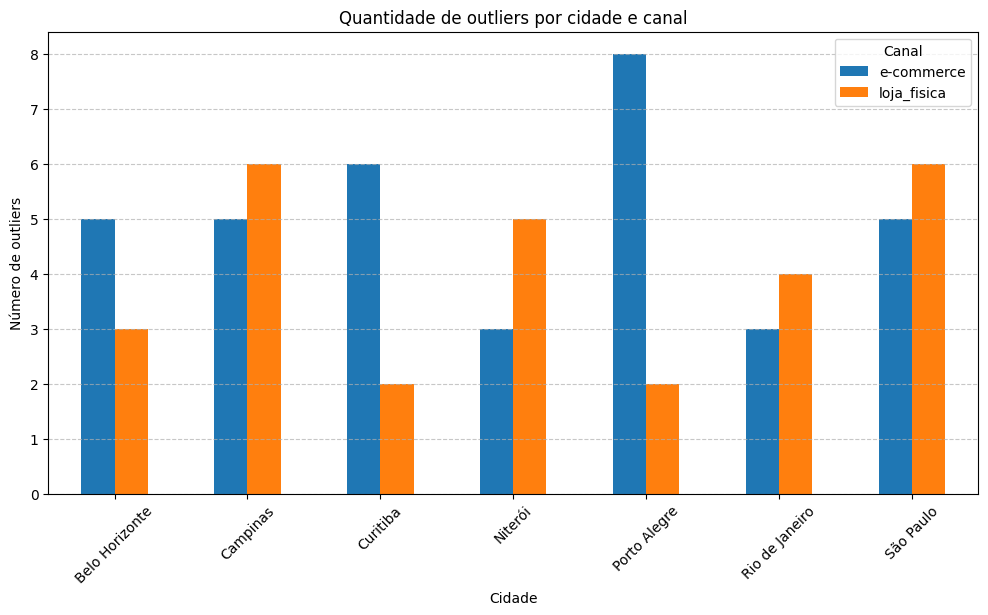

In [76]:
# Gráfico de barras agrupadas
df_outliers.plot(kind="bar", figsize=(12,6))
plt.title("Quantidade de outliers por cidade e canal")
plt.xlabel("Cidade")
plt.ylabel("Número de outliers")
plt.xticks(rotation=45)
plt.legend(title="Canal")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()